In [ ]:
# 🌿 Smart Agriculture Disease Advisor

## Disease Prediction

### Objective

This notebook demonstrates how to use the trained CNN model to predict plant diseases from unseen leaf images. It includes image preprocessing, model inference, confidence score calculation, and visualization of prediction results.

### Goals

- Load the trained CNN model
- Upload a leaf image
- Preprocess the image
- Predict the disease class
- Display prediction confidence
- Visualize the prediction

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image

from google.colab import files

In [3]:
!kaggle datasets download -d mohitsingh1804/plantvillage
!unzip -oq plantvillage.zip -d /content/plantvillage

Dataset URL: https://www.kaggle.com/datasets/mohitsingh1804/plantvillage
License(s): GPL-2.0
100% 818M/818M [00:06<00:00, 129MB/s]



In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith(".keras"):
            print(os.path.join(root, file))

/content/drive/MyDrive/plant_disease_cnn.keras


In [7]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/plant_disease_cnn.keras",
    compile=False
)

In [8]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/plant_disease_cnn.keras",
    compile=False
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Model Loaded Successfully")

✅ Model Loaded Successfully


In [11]:
from google.colab import files

In [12]:
uploaded = files.upload()

Saving Screenshot 2026-08-02 205406.png to Screenshot 2026-08-02 205406.png


In [13]:
image_path = list(uploaded.keys())[0]

print(image_path)

Screenshot 2026-08-02 205406.png


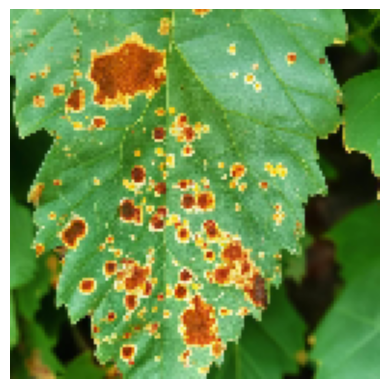

In [14]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

img = image.load_img(image_path, target_size=(128,128))

plt.imshow(img)
plt.axis("off")
plt.show()

In [15]:
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [17]:
import os

train_path = "/content/plantvillage/PlantVillage/train"
class_names = sorted(os.listdir(train_path))

In [18]:
prediction = model.predict(img_array)

predicted_index = np.argmax(prediction)
confidence = np.max(prediction)

print("Predicted Disease:", class_names[predicted_index])
print(f"Confidence: {confidence*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted Disease: Peach___Bacterial_spot
Confidence: 99.92%


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


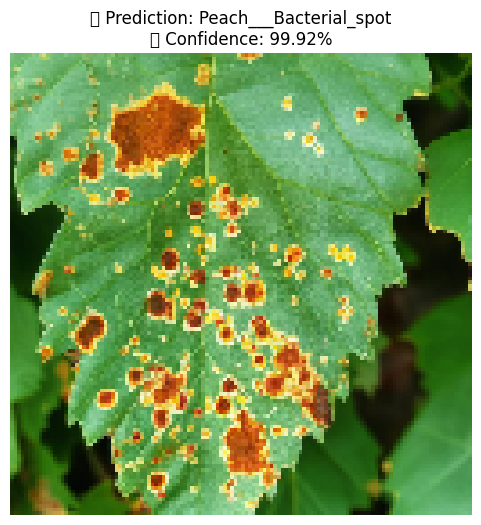

In [19]:
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(
    f"🌿 Prediction: {class_names[predicted_index]}\n"
    f"🎯 Confidence: {confidence*100:.2f}%"
)
plt.axis("off")
plt.show()